Loading real dataset from ~/Downloads/project/cicids2017_cleaned.csv...
Columns found: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg

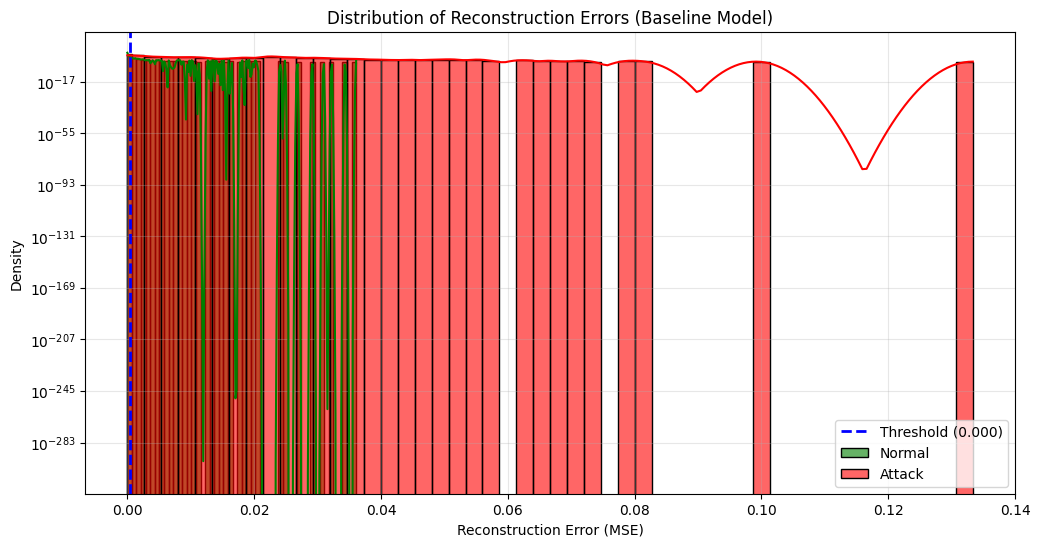

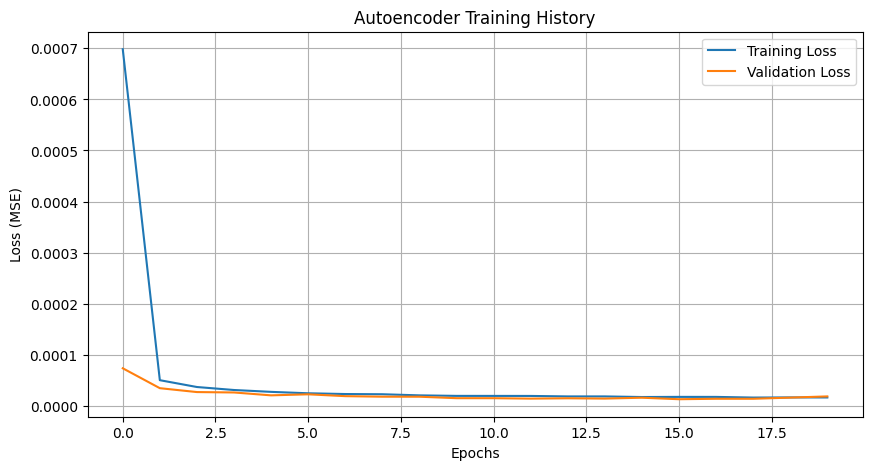

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# CONFIGURATION
# ==========================================
# Set this to True if you have the dataset downloaded locally
USE_REAL_DATA = True 
DATASET_PATH = '~/Downloads/project/cicids2017_cleaned.csv' # Path to your dataset

# Hyperparameters
INPUT_DIM = 78 # CICIDS2017 typically has ~78-80 usable features
LATENT_DIM = 8 # Size of the bottleneck layer (Compressed representation)
EPOCHS = 20
BATCH_SIZE = 64
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ==========================================
# 1. DATA LOADING & GENERATION
# ==========================================
def generate_dummy_data(n_samples=10000):
    """
    Generates a synthetic dataset mimicking the structure of CICIDS2017
    for testing the code logic.
    """
    print("Generating synthetic CICIDS2017-like data...")
    # Normal traffic (80%) - Lower values, specific patterns
    n_normal = int(n_samples * 0.8)
    normal_data = np.random.normal(loc=0.1, scale=0.05, size=(n_normal, INPUT_DIM))
    
    # Attack traffic (20%) - Higher values, different distribution (e.g., DoS)
    n_attack = n_samples - n_normal
    attack_data = np.random.normal(loc=0.6, scale=0.15, size=(n_attack, INPUT_DIM))
    
    # Combine
    X = np.vstack([normal_data, attack_data])
    # Clip to ensure valid range for simulation
    X = np.clip(X, 0, 1) 
    
    # Labels: 'BENIGN' for normal, 'DoS Hulk' for attacks
    y = np.array(['BENIGN'] * n_normal + ['DoS Hulk'] * n_attack)
    
    # Shuffle
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    df = pd.DataFrame(X[indices], columns=[f'Feature_{i}' for i in range(INPUT_DIM)])
    df['Label'] = y[indices]
    
    return df

def load_data():
    if USE_REAL_DATA:
        print(f"Loading real dataset from {DATASET_PATH}...")
        try:
            # encoding='utf-8-sig' handles the BOM character often found in CICIDS headers
            df = pd.read_csv(DATASET_PATH, encoding='utf-8-sig', low_memory=False)
        except Exception as e:
            print(f"Standard load failed. Retrying with cp1252. Error: {e}")
            df = pd.read_csv(DATASET_PATH, encoding='cp1252', low_memory=False)

        # 1. Clean column names (remove spaces and special chars)
        df.columns = df.columns.str.strip()
        print(f"Columns found: {df.columns.tolist()}")

        # 2. Smart Detection for Label Column
        target_col = None
        
        # Check 1: Exact or Case-insensitive match
        for col in df.columns:
            if 'label' in col.lower() or 'class' in col.lower():
                target_col = col
                break
        
        # Check 2: Fallback to the LAST column (Standard for CICIDS2017)
        if target_col is None:
            print("WARNING: 'Label' column not found by name. Using the LAST column as target.")
            target_col = df.columns[-1]

        print(f"Selected Target Column: '{target_col}'")

        # 3. Rename to 'Label' for consistency
        df.rename(columns={target_col: 'Label'}, inplace=True)
        
        return df
    else:
        return generate_dummy_data()

# Load the data
df = load_data()
print(f"Data Loaded. Shape: {df.shape}")
print("Class Distribution:\n", df['Label'].value_counts())

# ==========================================
# 2. DATA PREPROCESSING (FINAL FIX)
# ==========================================
print("\n--- Starting Preprocessing ---")

# 2.1 Cleaning
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(axis=0, how='any', inplace=True)

# 2.2 Identify Label Column & Normal Class
# Your dataset uses 'Normal Traffic' as the benign label
target_col = 'Label' # The load_data function has already renamed it to 'Label'

# Ensure the column exists
if target_col not in df.columns:
    # Fallback if load_data didn't rename it yet
    for col in df.columns:
        if 'attack' in col.lower() or 'label' in col.lower():
            target_col = col
            break
    df.rename(columns={target_col: 'Label'}, inplace=True)

# 2.3 Map Labels to Binary (0 = Normal, 1 = Attack)
# --- FIX: Explicitly define the list of normal labels ---
normal_labels = ['Normal Traffic', 'BENIGN']

print(f"Target Column: 'Label'")
print(f"Unique values before mapping: {df['Label'].unique()[:5]}")

# Apply the mapping
# We strip whitespace and check if the value is in our 'normal_labels' list
df['Label'] = df['Label'].apply(lambda x: 0 if str(x).strip() in normal_labels else 1)

# 2.4 Verify Splits
normal_count = len(df[df['Label'] == 0])
attack_count = len(df[df['Label'] == 1])
print(f"\nLabel Encoding Summary:")
print(f" - Normal Samples (0): {normal_count}")
print(f" - Attack Samples (1): {attack_count}")

if normal_count == 0:
    raise ValueError("CRITICAL: Still 0 normal samples. Please check the 'Unique values' print above.")

# 2.5 Feature Selection & Splitting
# Drop columns that are not useful or cause errors
cols_to_drop = ['Label']
X = df.drop(columns=cols_to_drop, errors='ignore') 
y = df['Label']

# 2.6 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# Update INPUT_DIM to match the actual number of features
INPUT_DIM = X_train.shape[1]
print(f"Updated INPUT_DIM to: {INPUT_DIM}")

# 2.7 Normalization
scaler = MinMaxScaler()
# Catch string errors
try:
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
except ValueError as e:
    print("\nScaling Error! You have non-numeric features.")
    print("Non-numeric columns:", X_train.select_dtypes(include=['object']).columns)
    raise e

# 2.8 Filter Normal Data for Autoencoder
train_index_normal = np.where(y_train == 0)
X_train_normal = X_train_scaled[train_index_normal]

print(f"\nData Ready:")
print(f" - Normal samples for AE training: {X_train_normal.shape}")
print(f" - Test set shape: {X_test_scaled.shape}")

# ==========================================
# 3. METHOD A: BASELINE AUTOENCODER
# ==========================================
print("\n Building and Training Baseline Autoencoder...")

# 3.1 Define Architecture (Deep Autoencoder)
input_layer = Input(shape=(INPUT_DIM,))

# Encoder
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(LATENT_DIM, activation='relu')(encoded) # Latent Space

# Decoder
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(INPUT_DIM, activation='sigmoid')(decoded) # Output scaled 0-1

# Create Model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# 3.2 Train (Unsupervised - X is both input and target)
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

# 3.3 Detect Anomalies (Reconstruction Error)
print("Calculating reconstruction errors...")
# Get reconstruction for the test set
X_test_pred = autoencoder.predict(X_test_scaled)
# Calculate Mean Squared Error per sample
mse = np.mean(np.power(X_test_scaled - X_test_pred, 2), axis=1)

# 3.4 Determine Threshold
# Simple statistical threshold: Mean + 2 * StdDev of the Normal Training Errors
# (Or we can use the errors from the test set normal samples to be safer)
threshold = np.mean(mse[y_test==0]) + 2 * np.std(mse[y_test==0])
print(f"Anomaly Threshold: {threshold:.4f}")

# 3.5 Classification
y_pred_baseline = [1 if e > threshold else 0 for e in mse]

# ==========================================
# 4. METHOD B: HYBRID MODEL (NOVELTY)
# ==========================================
print("\n Training Novelty Hybrid Model (AE + Random Forest)...")

# 4.1 Feature Extraction using Encoder
# We create a separate model that just outputs the bottleneck layer
encoder_model = Model(inputs=autoencoder.input, outputs=bottleneck)

# Encode all training data (both normal and attack)
# Note: For the hybrid classifier, we use the FULL training set, not just normal
X_train_encoded = encoder_model.predict(X_train_scaled)
X_test_encoded = encoder_model.predict(X_test_scaled)

print(f"Original Feature Shape: {X_train_scaled.shape}")
print(f"Encoded Feature Shape: {X_train_encoded.shape} (Dimensionality Reduced)")

# 4.2 Train Random Forest on Compressed Features
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf_clf.fit(X_train_encoded, y_train)

# 4.3 Predict
y_pred_hybrid = rf_clf.predict(X_test_encoded)

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================
print("\n Comparative Evaluation...")

def print_metrics(y_true, y_pred, name):
    print(f"--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("-" * 30)

print_metrics(y_test, y_pred_baseline, "Baseline (Reconstruction Error)")
print_metrics(y_test, y_pred_hybrid, "Hybrid (Encoder + RF)")

# 5.1 Visualization: Reconstruction Error Histogram
plt.figure(figsize=(12, 6))
sns.histplot(mse[y_test==0], bins=50, kde=True, color='green', label='Normal', stat='density', alpha=0.6)
sns.histplot(mse[y_test==1], bins=50, kde=True, color='red', label='Attack', stat='density', alpha=0.6)
plt.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.3f})')
plt.title('Distribution of Reconstruction Errors (Baseline Model)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.yscale('log') # Log scale is often better for seeing the tail of attacks
plt.grid(True, alpha=0.3)
plt.show()

# 5.2 Visualization: Model Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()